In [1]:
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

big = pd.read_csv("../data/mdm2_data_files/big_table_with_weather_rain_clusters_cctv300m.csv")

safety = pd.read_csv("../reports/sensor_ward_safety_after_dark_2024.csv")

print(big.shape)
print(safety.shape)

/Users/shavarshmelikyan/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/shavarshmelikyan/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


(379477, 20)
(46, 3)


In [2]:
df = big.merge(safety[["sensor_id","safety_after_dark_pct"]], on="sensor_id", how="left")

# scale safety
df["safety_scaled"] = df["safety_after_dark_pct"] / 100

print(df.head())

   ped  car  cyc  sensor_id                   datetime  hour   date_only  dow  \
0  413  381    9          1  2024-01-01 00:00:00+00:00     0  2024-01-01    0   
1  402  489   10          1  2024-01-01 01:00:00+00:00     1  2024-01-01    0   
2  421  473   10          1  2024-01-01 02:00:00+00:00     2  2024-01-01    0   
3  370  419    4          1  2024-01-01 03:00:00+00:00     3  2024-01-01    0   
4  132  123    2          1  2024-01-01 04:00:00+00:00     4  2024-01-01    0   

   longitude   latitude  ...  solar_altitude_deg  light_class  Dark temp_c  \
0  -2.591538  51.453815  ...          -61.529806     darkness     1    7.8   
1  -2.591538  51.453815  ...          -60.225898     darkness     1    8.0   
2  -2.591538  51.453815  ...          -54.953852     darkness     1    8.0   
3  -2.591538  51.453815  ...          -47.266506     darkness     1    7.6   
4  -2.591538  51.453815  ...          -38.404055     darkness     1    7.4   

   wind_ms  rain_mm  cluster_geo  cctv_300m 

In [4]:
formula = """
ped ~ 
C(cluster_geo) + C(hour) + C(dow) + C(month)
+ temp_c + wind_ms + rain_mm
+ Dark
+ safety_scaled
+ Dark:safety_scaled
"""

# 1) keep only columns used by the model
needed_cols = [
    "ped","cluster_geo","hour","dow","month",
    "temp_c","wind_ms","rain_mm",
    "Dark","safety_scaled","sensor_id"
]

df_m = df[needed_cols].copy()

# 2) drop rows with any missing values in model variables
df_m = df_m.dropna()

print("Rows before:", len(df))
print("Rows after NA drop:", len(df_m))
print("Missing safety rows dropped:", df["safety_scaled"].isna().sum())

# 3) fit with groups aligned to df_m
model = smf.glm(
    formula=formula,
    data=df_m,
    family=sm.families.NegativeBinomial()
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_m["sensor_id"]}
)

print(model.summary())

Rows before: 379477
Rows after NA drop: 378005
Missing safety rows dropped: 0
                 Generalized Linear Model Regression Results                  
Dep. Variable:                    ped   No. Observations:               378005
Model:                            GLM   Df Residuals:                   377956
Model Family:        NegativeBinomial   Df Model:                           48
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.8464e+06
Date:                Thu, 05 Mar 2026   Deviance:                   8.3767e+05
Time:                        12:52:23   Pearson chi2:                 1.56e+06
No. Iterations:                    54   Pseudo R-squ. (CS):             0.7397
Covariance Type:              cluster                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------

In [5]:
dispersion = model.pearson_chi2 / model.df_resid
print("Dispersion:", dispersion)

Dispersion: 4.136065710225845


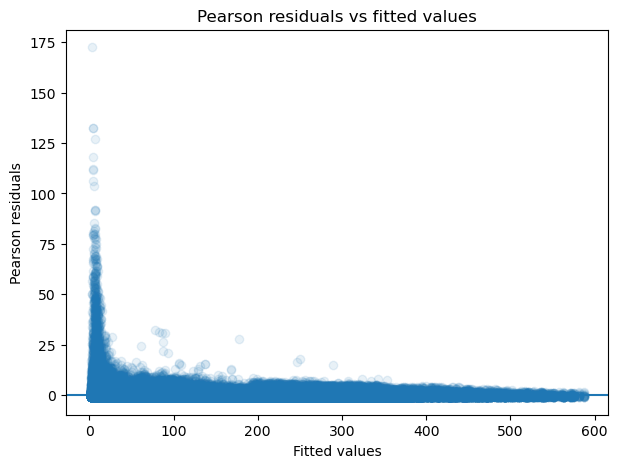

In [6]:
resid = model.resid_pearson
fitted = model.fittedvalues

plt.figure(figsize=(7,5))
plt.scatter(fitted, resid, alpha=0.1)
plt.axhline(0)
plt.xlabel("Fitted values")
plt.ylabel("Pearson residuals")
plt.title("Pearson residuals vs fitted values")
plt.show()

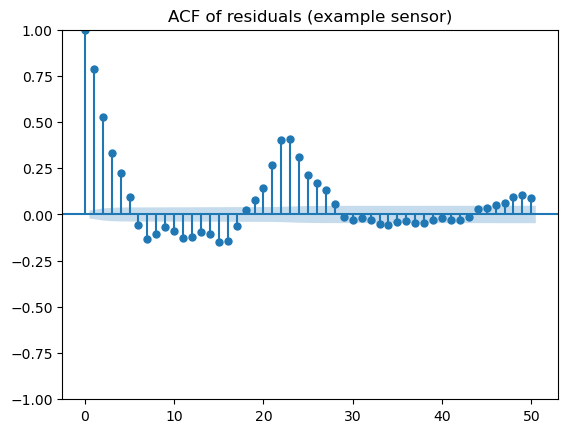

In [7]:
sensor_example = df["sensor_id"].iloc[0]

resid_sensor = resid[df["sensor_id"] == sensor_example]

plot_acf(resid_sensor, lags=50)
plt.title("ACF of residuals (example sensor)")
plt.show()

In [8]:
coef_dark = model.params["Dark"]

effect = (pow(2.718, coef_dark) - 1) * 100

print("Darkness effect (% change):", effect)

Darkness effect (% change): -14.987811986336263


In [11]:
import os
OUT_FIG_DIR = "../figures"
OUT_REP_DIR = "../reports"
TAG = "ped_safety"   # change later to "cyc_safety" and "active_safety"

os.makedirs(OUT_FIG_DIR, exist_ok=True)
os.makedirs(OUT_REP_DIR, exist_ok=True)

# 1) Save model summary to text
summary_path = os.path.join(OUT_REP_DIR, f"glm_{TAG}_summary.txt")
with open(summary_path, "w") as f:
    f.write(model.summary().as_text())

print("Saved model summary:", summary_path)

# 2) Save coefficients table to CSV
coef_table = pd.DataFrame({
    "term": model.params.index,
    "coef": model.params.values,
    "std_err": model.bse.values,
    "z": model.tvalues.values,
    "p_value": model.pvalues.values,
    "ci_low": model.conf_int()[0].values,
    "ci_high": model.conf_int()[1].values
})
coef_path = os.path.join(OUT_REP_DIR, f"glm_{TAG}_coefficients.csv")
coef_table.to_csv(coef_path, index=False)
print("Saved coefficients:", coef_path)

# 3) Save diagnostics (dispersion + Ljung-Box if you computed it)
diag = {"dispersion": [dispersion]}
diag_df = pd.DataFrame(diag)
diag_path = os.path.join(OUT_REP_DIR, f"glm_{TAG}_diagnostics.csv")
diag_df.to_csv(diag_path, index=False)
print("Saved diagnostics:", diag_path)

# If you created a Ljung-Box table called `lb` (DataFrame), save it too
if "lb" in globals():
    lb_path = os.path.join(OUT_REP_DIR, f"glm_{TAG}_ljung_box.csv")
    lb.to_csv(lb_path, index=True)
    print("Saved Ljung-Box:", lb_path)

# 4) Save plots (expects you created fig objects or can recreate them)
# If your notebook created matplotlib figures as `fig1`, `fig2`, `fig3`, save them
def save_fig(fig, name):
    png_path = os.path.join(OUT_FIG_DIR, f"{name}.png")
    pdf_path = os.path.join(OUT_FIG_DIR, f"{name}.pdf")
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    print("Saved:", png_path)
    print("Saved:", pdf_path)

# Common figure variable names you likely used
if "fig_acf" in globals():
    save_fig(fig_acf, f"acf_residuals_{TAG}")
if "fig_resid" in globals():
    save_fig(fig_resid, f"residuals_vs_fitted_{TAG}")
if "fig_dark" in globals():
    save_fig(fig_dark, f"darkness_effect_{TAG}")



Saved model summary: ../reports/glm_ped_safety_summary.txt
Saved coefficients: ../reports/glm_ped_safety_coefficients.csv
Saved diagnostics: ../reports/glm_ped_safety_diagnostics.csv


In [14]:
effects = []

for c in sorted(df["cluster_geo"].unique()):
    sub = df[df["cluster_geo"] == c].copy()

    sub_day = sub.copy()
    sub_day["Dark"] = 0
    mu_day = model.predict(sub_day).mean()

    sub_dark = sub.copy()
    sub_dark["Dark"] = 1
    mu_dark = model.predict(sub_dark).mean()

    pct = (mu_dark - mu_day) / mu_day * 100
    effects.append({"cluster": c, "darkness_effect_percent": pct})

effects_df = pd.DataFrame(effects)
effects_df

,cluster,darkness_effect_percent
0,0,-40.789046
1,1,-52.865723
2,2,-45.930785


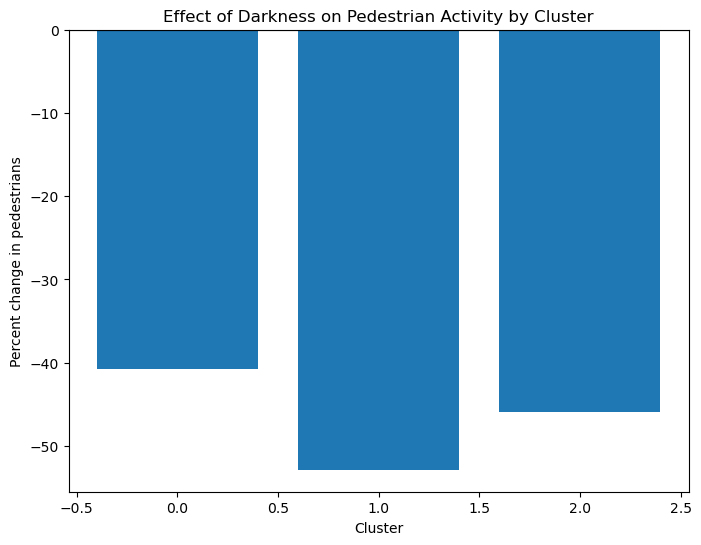

In [15]:
plt.figure(figsize=(8,6))
plt.bar(effects_df["cluster"], effects_df["darkness_effect_percent"])
plt.axhline(0, color="black")
plt.xlabel("Cluster")
plt.ylabel("Percent change in pedestrians")
plt.title("Effect of Darkness on Pedestrian Activity by Cluster")
plt.show()

In [16]:
plt.savefig("../figures/darkness_effect_clusters_ped.png", dpi=300, bbox_inches="tight")
plt.savefig("../figures/darkness_effect_clusters_ped.pdf", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>